# POPNET MultiLayeredNetwork Tutorial

<span style="font-size:13pt">In this tutorial we show how the MultiLayeredNetwork (MLN) class can be used to work with the POPNET network. For that we go through the relevant methods and show simple examples of how to use them. We show most functionalities on a subgraph of the network to keep processing times lower, but since this is also an MLN class, everything of course also works on the entire network.</span>

<span style="font-size:13pt">To import the class:</span>

In [1]:
# might need to be altered depending on where mln.py is located, I used the git version in a sibling folder of my working dir
import sys
sys.path.append("../..")
from popnet_mln.mln import MultiLayeredNetwork

<br><span style="font-size:13pt">To create an instance of the MLN class using all POPNET data:</span>

In [2]:
popnet = MultiLayeredNetwork(
    from_library="full_new",
    linktypes_file="/data/projecten/popnet/meta/linktypes_en_extended_full.csv"
)

Reading node attribute files...
Done.
Loading adjacency matrix...
Done.


<br>

---

## Filtering

<span style="font-size:13pt">To get a list of all IDs of people in a certain gemeente using the gemeente code, e.g. for Oegstgeest:</span>

In [3]:
oegstgeest_ids = popnet.node_attributes.loc[popnet.node_attributes["gemeente_code"] == "GM0579"]["label"]
oegstgeest_ids

102              4622
310             17464
976             54685
1123            63434
1631            93073
              ...    
17253544    999782957
17253796    999798149
17254979    999868992
17256043    999933353
17256885    999981175
Name: label, Length: 24237, dtype: int64

<span style="font-size:13pt">Wijk codes and buurt codes can also be used in the same way, using the corresponding columns.</span>

<br><span style="font-size:13pt">For gemeentes, we can also directly use the name:</span>

In [4]:
oegstgeest_ids = popnet.node_attributes.loc[popnet.node_attributes["gemeente_name"] == "Oegstgeest"]["label"]
oegstgeest_ids

102              4622
310             17464
976             54685
1123            63434
1631            93073
              ...    
17253544    999782957
17253796    999798149
17254979    999868992
17256043    999933353
17256885    999981175
Name: label, Length: 24237, dtype: int64

<br><span style="font-size:13pt">To get an instance of the MLN class only containing **people with certain RINPERSOONs**, e.g. the people in Oegstgeest:</span>

In [5]:
oegstgeest = popnet.get_filtered_network(selected_nodes=oegstgeest_ids)

print("Number of people:", oegstgeest.N)
print("Number of connected pairs of people:", oegstgeest.A.nnz)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.
Number of people: 24237
Number of connected pairs of people: 938725


<br><span style="font-size:13pt">To get an instance of the MLN class containing just **certain layers**, e.g. the household and family layers:</span>

In [6]:
oegstgeest_house_fam = oegstgeest.get_filtered_network(full_layers=["household", "family"])

print("Number of people:", oegstgeest_house_fam.N)
print("Number of connected pairs of people:", oegstgeest_house_fam.A.nnz)

['household', 'family']
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.
Number of people: 24237
Number of connected pairs of people: 62594


<br><span style="font-size:13pt">To get an instance of the MLN class containing **certain link types**, e.g. 301, 401:</span>

In [7]:
oegstgeest_x01 = oegstgeest.get_filtered_network(layer_codes=[301, 401])

print("Number of people:", oegstgeest_x01.N)
print("Number of connected pairs of people:", oegstgeest_x01.A.nnz)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.
Number of people: 24237
Number of connected pairs of people: 564897


<br><span style="font-size:13pt">These filtering methods can also be used in **any combination**, e.g. all together:</span>

In [8]:
oegstgeest_filtered = popnet.get_filtered_network(
    selected_nodes=oegstgeest_ids,
    full_layers=["household", "family"],
    layer_codes=[301, 401]
)

print("Number of people:", oegstgeest_filtered.N)
print("Number of connected pairs of people:", oegstgeest_filtered.A.nnz)

['household', 'family']
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.
Number of people: 24237
Number of connected pairs of people: 626930


<br>

---

## Conversion to other formats

### igraph

<span style="font-size:13pt">Note that igraph automatically labels nodes from 0 through N-1 but these labels very likely do not line up with the mapping from IDs to RINPERSOONs as stored in `mln.nodemap_back`. However, we do always store the RINPERSOONs as node attributes.</span>

In [9]:
# prerequisites, also make sure to import the MLN class and create the
# `popnet` instance, as shown at the very start of this tutorial

import igraph as ig

# obtain an MLN object of all people living in the municipality of Oegstgeest
oegstgeest_ids = popnet.node_attributes.loc[popnet.node_attributes["gemeente_code"] == "GM0579"]["label"]
oegstgeest = popnet.get_filtered_network(selected_nodes=oegstgeest_ids)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.


---

<span style="font-size:13pt">To obtain an **igraph Graph object** representing the MLN:</span>

In [10]:
g_igraph = oegstgeest.to_igraph()

ig.summary(g_igraph) # print the node count, edge count, and a list of the available attributes

IGRAPH D--- 24237 938725 -- 
+ attr: label (v), link_types (e)


<br><span style="font-size:13pt">To obtain an **undirected** igraph Graph object of the MLN:</span>

In [11]:
g_igraph_u = oegstgeest.to_igraph(directed=False)

ig.summary(g_igraph_u)
print("Directed:", g_igraph_u.is_directed())

IGRAPH U--- 24237 517898 -- 
+ attr: label (v), link_types (e)
Directed: False


<br><span style="font-size:13pt">To **omit link types and node attributes** (except for the RINPERSOONs):</span>

In [12]:
g_igraph = oegstgeest.to_igraph(edge_attributes=False, node_attributes=False)

ig.summary(g_igraph)

IGRAPH D--- 24237 938725 -- 
+ attr: label (v), link_types (e)


<br><span style="font-size:13pt">The igraph objects are also stored in the `igraph` attribute of the MLN class. Unless we specify otherwise, only the result from the first call to `.get_igraph()` will be stored. To overwrite this:</span>

In [13]:
print("Before:")
ig.summary(oegstgeest.igraph)

# overwrite using replace_igraph=True
oegstgeest.to_igraph(replace_igraph=True, directed=False, node_attributes=False)

print("\nAfter:")
ig.summary(oegstgeest.igraph)

Before:
IGRAPH D--- 24237 938725 -- 
+ attr: label (v), link_types (e)

After:
IGRAPH U--- 24237 517898 -- 
+ attr: label (v), link_types (e)


<br>

---

### NetworkX

<span style="font-size:13pt">Note that NetworkX automatically labels nodes from 0 through N-1 but these labels very likely do not line up with the mapping from IDs to RINPERSOONs as stored in `mln.nodemap_back`. However, we do always store the RINPERSOONs as node attributes.</span>

In [14]:
# prerequisites, also make sure to import the MLN class and create the
# `popnet` instance, as shown at the very start of this tutorial

import networkx as nx

# obtain an MLN object of all people living in the municipality of Oegstgeest
oegstgeest_ids = popnet.node_attributes.loc[popnet.node_attributes["gemeente_code"] == "GM0579"]["label"]
oegstgeest = popnet.get_filtered_network(selected_nodes=oegstgeest_ids)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.


---

<span style="font-size:13pt">We can also obtain a **NetworkX graph** representation of the MLN. Since NetworkX is a less efficient library, we recommend to only use if for networks smaller than `mln.nx_limit`. To create a NetworkX graph for a network that is larger (otherwise simply leave out the `node_limit_False`):</span>

In [15]:
g_nx = oegstgeest.to_networkx(ignore_limit=True)

print(nx.info(g_nx))

Name: 
Type: DiGraph
Number of nodes: 24237
Number of edges: 938725
Average in degree:  38.7311
Average out degree:  38.7311


<br><span style="font-size:13pt">To obtain an **undirected** version of the network:</span>

In [16]:
g_nx = oegstgeest.to_networkx(directed=False, ignore_limit=True)

print(nx.info(g_nx))

Name: 
Type: Graph
Number of nodes: 24237
Number of edges: 517898
Average degree:  42.7361


<br><span style="font-size:13pt">To **node attributes** (except for the RINPERSOONs):</span>

In [17]:
print(g_nx.nodes[0])
print(g_nx.edges[0, 252]) # inspect one link manually to show the link type

# new graph without node and edge attributes
g_nx = oegstgeest.to_networkx(edge_attributes=False, node_attributes=False, ignore_limit=True)

print()
print(g_nx.nodes[0])
print(g_nx.edges[0, 252])

{'label': 0}
{'link_types': ['neighbor']}

{'label': 0}
{}


<span style="font-size:13pt">The NetworkX networks are not stored directly as an attribute of the MLN class, and so there is no replace function as there is for igraph.</span>

<br>

---


## Exporting and importing

In [18]:
# prerequisites, also make sure to import the MLN class and create the
# `popnet` instance, as shown at the very start of this tutorial

import pandas as pd

# obtain an MLN object of all people living in the municipality of Oegstgeest
oegstgeest_ids = popnet.node_attributes.loc[popnet.node_attributes["gemeente_name"] == "Oegstgeest"]["label"]
oegstgeest = popnet.get_filtered_network(selected_nodes=oegstgeest_ids)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.


<span style="font-size:13pt">Per default, libraries are stored in `/data/projecten/popnet/library`. As not to clutter this shared directory, we set the storage path to the current directory:</span>

In [19]:
import os
oegstgeest.library_path = os.getcwd()

---

<span style="font-size:13pt">To **export all data** in an MLN object to a library:</span>

In [20]:
oegstgeest.export(library_name="oegstgeest_full_new")

Library "/data/home/secrjjg@cbsp.nl/popnet/popnet_mln/tutorial/oegstgeest_full_new" already exists, call function with `overwrite = True` keyword argument if you're sure!


<span style="font-size:13pt">If a folder with the given name already exists, we can overwrite it with the argument `overwrite=True`.</span>

<br><span style="font-size:13pt">To **import** from a libary:</span>

In [21]:
oegstgeest2 = MultiLayeredNetwork(
    from_library="oegstgeest_full_new"
)

Reading node attribute files...
Loading attributes.csv.gz
Done. Pickling with current pandas version
Done.
Loading adjacency matrix...
Done.


<br><span style="font-size:13pt">The **node attributes** can also be exported separately:</span>

In [22]:
oegstgeest.export_node_attributes("oegstgeest_node_attrs.csv.gz")

<span style="font-size:13pt">Uncompressed files and other file separators are also available.</span>

<br><span style="font-size:13pt">The **adjacency matrix** can also be exported separately:</span>

In [23]:
oegstgeest.export_graph("oegstgeest_graph.graphml")

<span style="font-size:13pt">Other file types and separators are also available.</span>

<br>

---

## Other functionalities / examples

In [24]:
# prerequisites, also make sure to import the MLN class and create the
# `popnet` instance, as shown at the very start of this tutorial

# obtain an MLN object of all people living in the municipality of Oegstgeest
oegstgeest_ids = popnet.node_attributes.loc[popnet.node_attributes["gemeente_name"] == "Oegstgeest"]["label"]
oegstgeest = popnet.get_filtered_network(selected_nodes=oegstgeest_ids)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.


---

<span style="font-size:13pt">To obtain the ego network of a person at a certain depth:</span>

In [25]:
# mln.nodemap_back[0] returns the RINPERSOON of person 0 
#ids, A, node_attrs = oegstgeest.get_egonetwork(oegstgeest.nodemap_back[0], depth=2)
ego = oegstgeest.get_egonetwork(oegstgeest.map_nid_to_label[0], depth=2)

[]
Reading node attribute files...
Done.
Loading adjacency matrix...
Done.


<br><span style="font-size:13pt">To create an affiliation matrix between people and a certain attribute, e.g. work IDs under key "work":</span>

In [26]:
# first create an edgelist of (person, attribute value) pairs 
affiliation_edgelist = oegstgeest.node_attributes.set_index("label")['work_id'].dropna().to_dict().items()

# create the affiliation matrix, under key 'work'
oegstgeest.create_affiliation_matrix('work', affiliation_edgelist)

<span style="font-size:13pt">This affiliation matrix is now stored in `.affiliation_matrix`, which is a dictionary that can store several affiliation matrices. We can acces the one that was just made with key "work" using:</span>

In [27]:
oegstgeest.affiliation_matrix["work"]["A"]

<24237x3917 sparse matrix of type '<class 'numpy.int64'>'
	with 10346 stored elements in Compressed Sparse Row format>

<br><span style="font-size:13pt">To count people for different values of an attributes and make a bar plot, e.g. counting the number of people in the country parts:</span>

<AxesSubplot:>

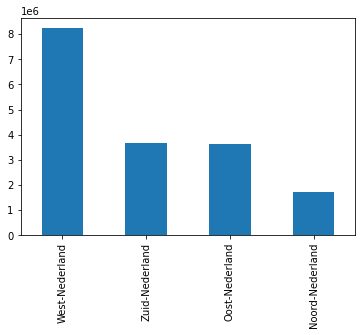

In [28]:
countrypart_populations = popnet.node_attributes['countrypart'].value_counts()
# string mapping is necessary, since JSON keys are strictly strings
countrypart_populations.index = countrypart_populations.index.astype(str).map(popnet.attribute_code_table["countrypart"])
countrypart_populations.plot(kind='bar')